# Quadrant distribution across sources
For each source × quadrant: chunk counts and mean axis scores.

In [29]:
import json
import random
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
import pandas as pd

BASE      = Path("../data/experts/quadrant_pools")
SOURCES   = ["allsides", "ec_press", "ire_press", "uk_press", "hoc", "reddit_liberal", "reddit_conservative"]
QUADRANTS = ["right_auth", "left_auth", "left_lib", "right_lib"]

# Q1=right_auth, Q2=left_auth, Q3=left_lib, Q4=right_lib
Q_LABEL = {
    "right_auth": "Q1 (right_auth)",
    "left_auth":  "Q2 (left_auth)",
    "left_lib":   "Q3 (left_lib)",
    "right_lib":  "Q4 (right_lib)",
}
Q_SHORT = {
    "right_auth": "Q1",
    "left_auth":  "Q2",
    "left_lib":   "Q3",
    "right_lib":  "Q4",
}
COLORS = {
    "right_auth": "#9dc5e2", # blue
    "left_auth":  "#e17a7a", # red
    "left_lib":   "#aee8bf", # green
    "right_lib":  "#fbf09e", # yellow
}
SOURCE_LABEL = {
    "allsides":            "AllSides",
    "ec_press":            "EC Press Releases",
    "ire_press":           "Irish Gov. Press Releases",
    "uk_press":            "UK Gov. Press Releases",
    "hoc":                 "UK House of Commons",
    "reddit_liberal":      "Reddit (Liberal)",
    "reddit_conservative": "Reddit (Conservative)",
}

In [16]:
records = []

for source in SOURCES:
    path = BASE / source / "scored_chunks.jsonl"
    buckets = defaultdict(lambda: {"econ": [], "soc": [], "abs_econ": [], "abs_soc": [], "conf": []})
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            q = d["quadrant"]
            ae, as_ = d["score_abs_econ"], d["score_abs_soc"]
            if ae == ae:   buckets[q]["abs_econ"].append(ae)
            if as_ == as_: buckets[q]["abs_soc"].append(as_)
            e, s = d["score_econ"], d["score_soc"]
            if e == e: buckets[q]["econ"].append(e)
            if s == s: buckets[q]["soc"].append(s)
            c = d["confidence_margin"]
            if c == c: buckets[q]["conf"].append(c)

    total = sum(len(v["econ"]) for v in buckets.values())
    for q in QUADRANTS:
        b = buckets[q]
        n = len(b["econ"])
        records.append({
            "source":        source,
            "quadrant":      q,
            "n_chunks":      n,
            "pct_of_source": 100 * n / total if total else 0,
            "mean_econ":     float(np.mean(b["econ"]))     if b["econ"]     else float("nan"),
            "mean_soc":      float(np.mean(b["soc"]))      if b["soc"]      else float("nan"),
            "mean_abs_econ": float(np.mean(b["abs_econ"])) if b["abs_econ"] else float("nan"),
            "mean_abs_soc":  float(np.mean(b["abs_soc"]))  if b["abs_soc"]  else float("nan"),
            "mean_conf":     float(np.mean(b["conf"]))     if b["conf"]     else float("nan"),
        })

df = pd.DataFrame(records)
df["q_label"] = df["quadrant"].map(Q_LABEL)
print(df[["source", "q_label", "n_chunks", "mean_econ", "mean_soc", "mean_abs_econ", "mean_abs_soc", "mean_conf"]]
      .to_string(index=False, float_format="{:.4f}".format))

             source         q_label  n_chunks  mean_econ  mean_soc  mean_abs_econ  mean_abs_soc  mean_conf
           allsides Q1 (right_auth)      5353     0.0269    0.0108         0.0269        0.0108     0.0093
           allsides  Q2 (left_auth)       259    -0.0061    0.0142         0.0061        0.0142     0.0050
           allsides   Q3 (left_lib)       549    -0.0075   -0.0282         0.0075        0.0282     0.0067
           allsides  Q4 (right_lib)     12231     0.0286   -0.0195         0.0286        0.0195     0.0149
           ec_press Q1 (right_auth)      1604     0.0049    0.0130         0.0049        0.0130     0.0038
           ec_press  Q2 (left_auth)     27916    -0.0225    0.0140         0.0225        0.0140     0.0109
           ec_press   Q3 (left_lib)     39221    -0.0253   -0.0209         0.0253        0.0209     0.0152
           ec_press  Q4 (right_lib)      2524     0.0058   -0.0202         0.0058        0.0202     0.0050
          ire_press Q1 (right_auth)  

## Chunk counts per source × quadrant

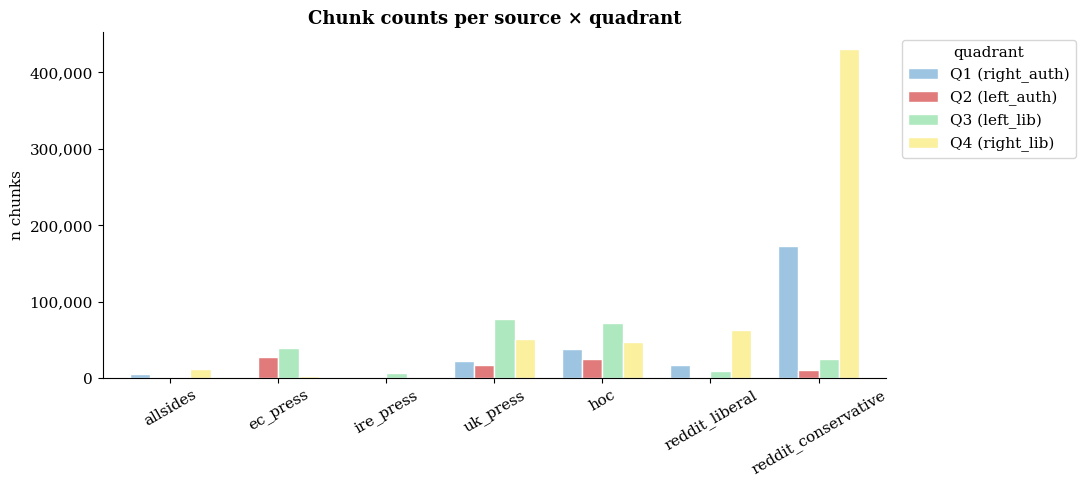

In [30]:
pivot_n = df.pivot(index="source", columns="quadrant", values="n_chunks")[QUADRANTS]
pivot_n.index = pd.CategoricalIndex(pivot_n.index, categories=SOURCES, ordered=True)
pivot_n = pivot_n.sort_index()
pivot_n.columns = [Q_LABEL[q] for q in QUADRANTS]

fig, ax = plt.subplots(figsize=(11, 5))
pivot_n.plot(kind="bar", ax=ax, color=[COLORS[q] for q in QUADRANTS], width=0.75, edgecolor="white")
ax.set_title("Chunk counts per source × quadrant", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("n chunks")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.tick_params(axis="x", rotation=30)
ax.legend(title="quadrant", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Quadrant share within each source (% of source total)

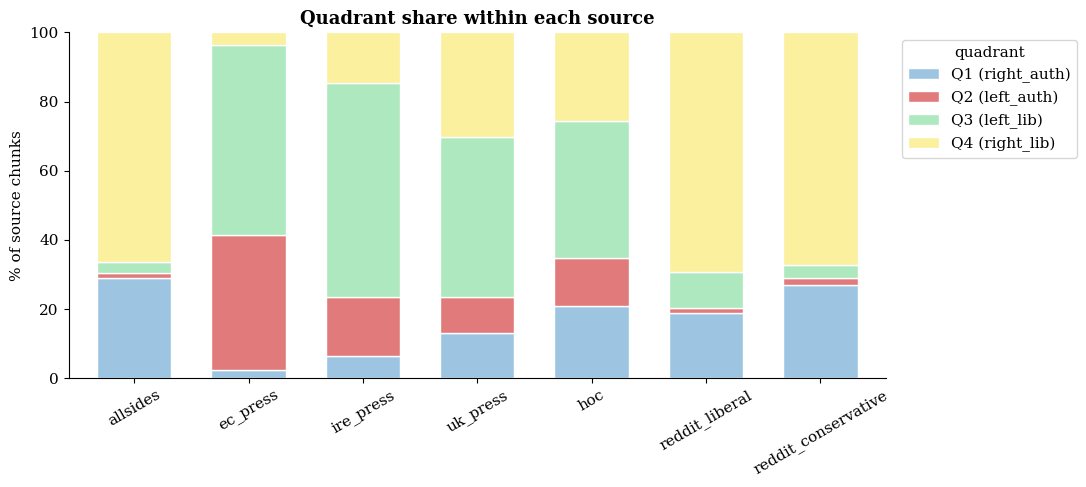

In [31]:
pivot_pct = df.pivot(index="source", columns="quadrant", values="pct_of_source")[QUADRANTS]
pivot_pct.index = pd.CategoricalIndex(pivot_pct.index, categories=SOURCES, ordered=True)
pivot_pct = pivot_pct.sort_index()
pivot_pct.columns = [Q_LABEL[q] for q in QUADRANTS]

fig, ax = plt.subplots(figsize=(11, 5))
pivot_pct.plot(kind="bar", stacked=True, ax=ax, color=[COLORS[q] for q in QUADRANTS], width=0.65, edgecolor="white")
ax.set_title("Quadrant share within each source", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("% of source chunks")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="quadrant", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Mean ideological scores per source × quadrant
Each bubble marks the mean (econ, soc) score of chunks assigned to that quadrant. Bubble area ∝ number of chunks.

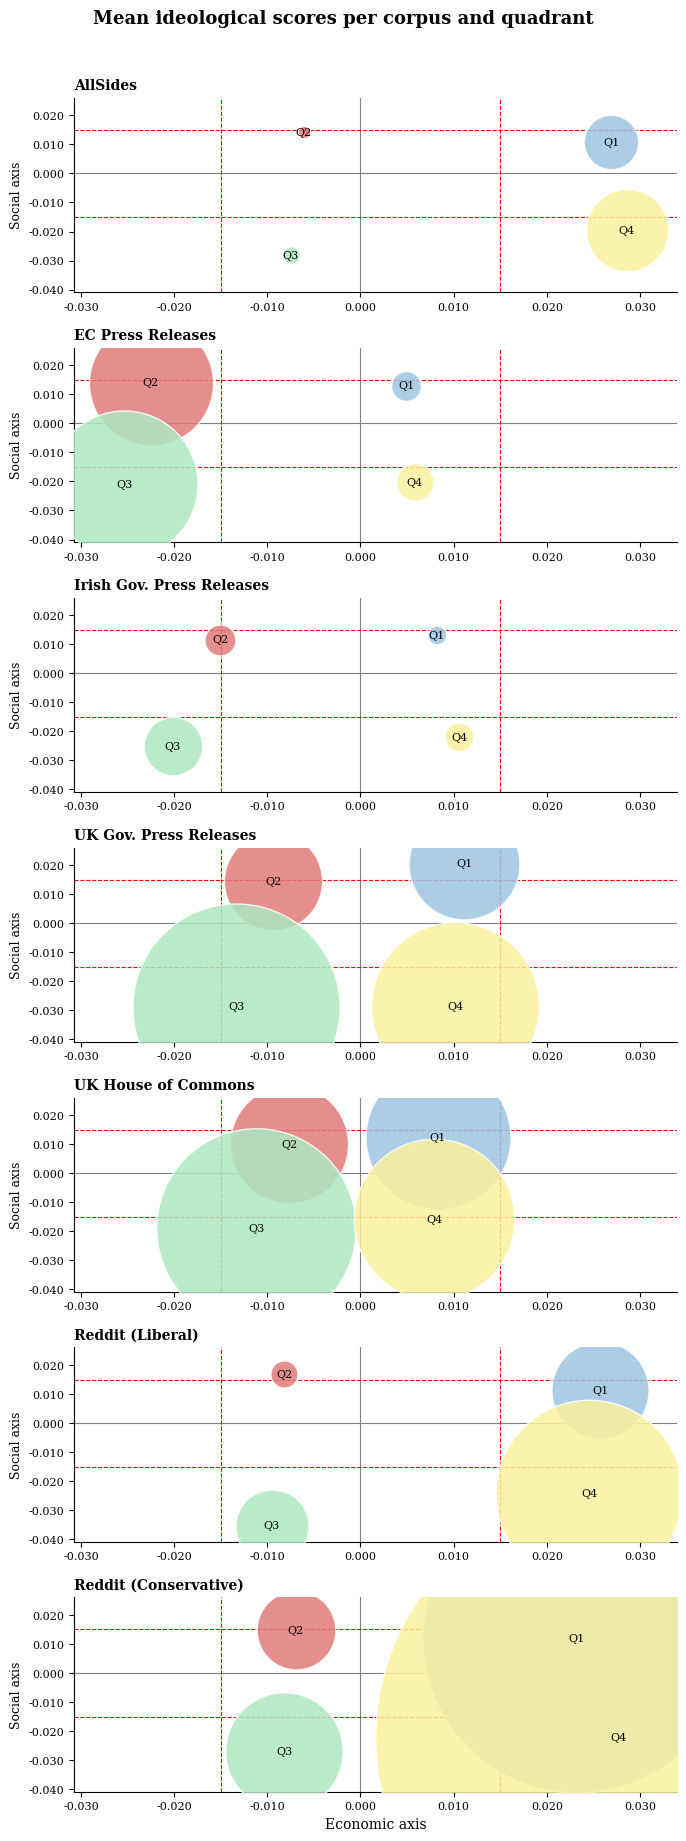

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# === USER INPUT ===
X = 0.015  # set your threshold here

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

n_src = len(SOURCES)
fig, axes = plt.subplots(
    n_src, 1,
    figsize=(7, 2.6 * n_src),
    sharex=True,
    sharey=True,
)

if n_src == 1:
    axes = [axes]

# zoom to actual data range, but include thresholds too
x_all = df["mean_econ"].to_numpy()
y_all = df["mean_soc"].to_numpy()

x_min = min(x_all.min(), -X)
x_max = max(x_all.max(),  X)
y_min = min(y_all.min(), -X)
y_max = max(y_all.max(),  X)

x_pad = max((x_max - x_min) * 0.10, 0.002)
y_pad = max((y_max - y_min) * 0.10, 0.002)

xlim = (x_min - x_pad, x_max + x_pad)
ylim = (y_min - y_pad, y_max + y_pad)

SIZE_SCALE = 3500

for ax, source in zip(axes, SOURCES):
    sub = df[df["source"] == source]

    # central axes
    ax.axhline(0, color="gray", lw=0.8, zorder=1)
    ax.axvline(0, color="gray", lw=0.8, zorder=1)

    # threshold lines
    ax.axhline(+X, color="red", lw=0.8, ls="--", zorder=1)
    ax.axhline(-X, color="red", lw=0.8, ls="--", zorder=1)
    ax.axvline(+X, color="red", lw=0.8, ls="--", zorder=1)
    ax.axvline(-X, color="red", lw=0.8, ls="--", zorder=1)

    for _, row in sub.iterrows():
        q = row["quadrant"]
        me = row["mean_econ"]
        ms = row["mean_soc"]
        n = row["n_chunks"]

        ax.scatter(
            me,
            ms,
            s=max(n / SIZE_SCALE * 1000, 80),
            color=COLORS[q],
            alpha=0.85,
            edgecolors="white",
            linewidths=1,
            zorder=3,
        )

        ax.text(
            me,
            ms,
            Q_SHORT[q],
            ha="center",
            va="center",
            fontsize=8,
            color="black",
            zorder=4,
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_title(SOURCE_LABEL[source], fontsize=10, fontweight="bold", loc="left")
    ax.set_ylabel("Social axis", fontsize=9)

    # numeric ticks on every subplot
    ax.tick_params(axis="x", labelbottom=True, labelsize=8)
    ax.tick_params(axis="y", labelleft=True, labelsize=8)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))

axes[-1].set_xlabel("Economic axis", fontsize=10)

fig.suptitle(
    "Mean ideological scores per corpus and quadrant",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.savefig(
    "../data/experts/quadrant_pools/mean_scores_by_source.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

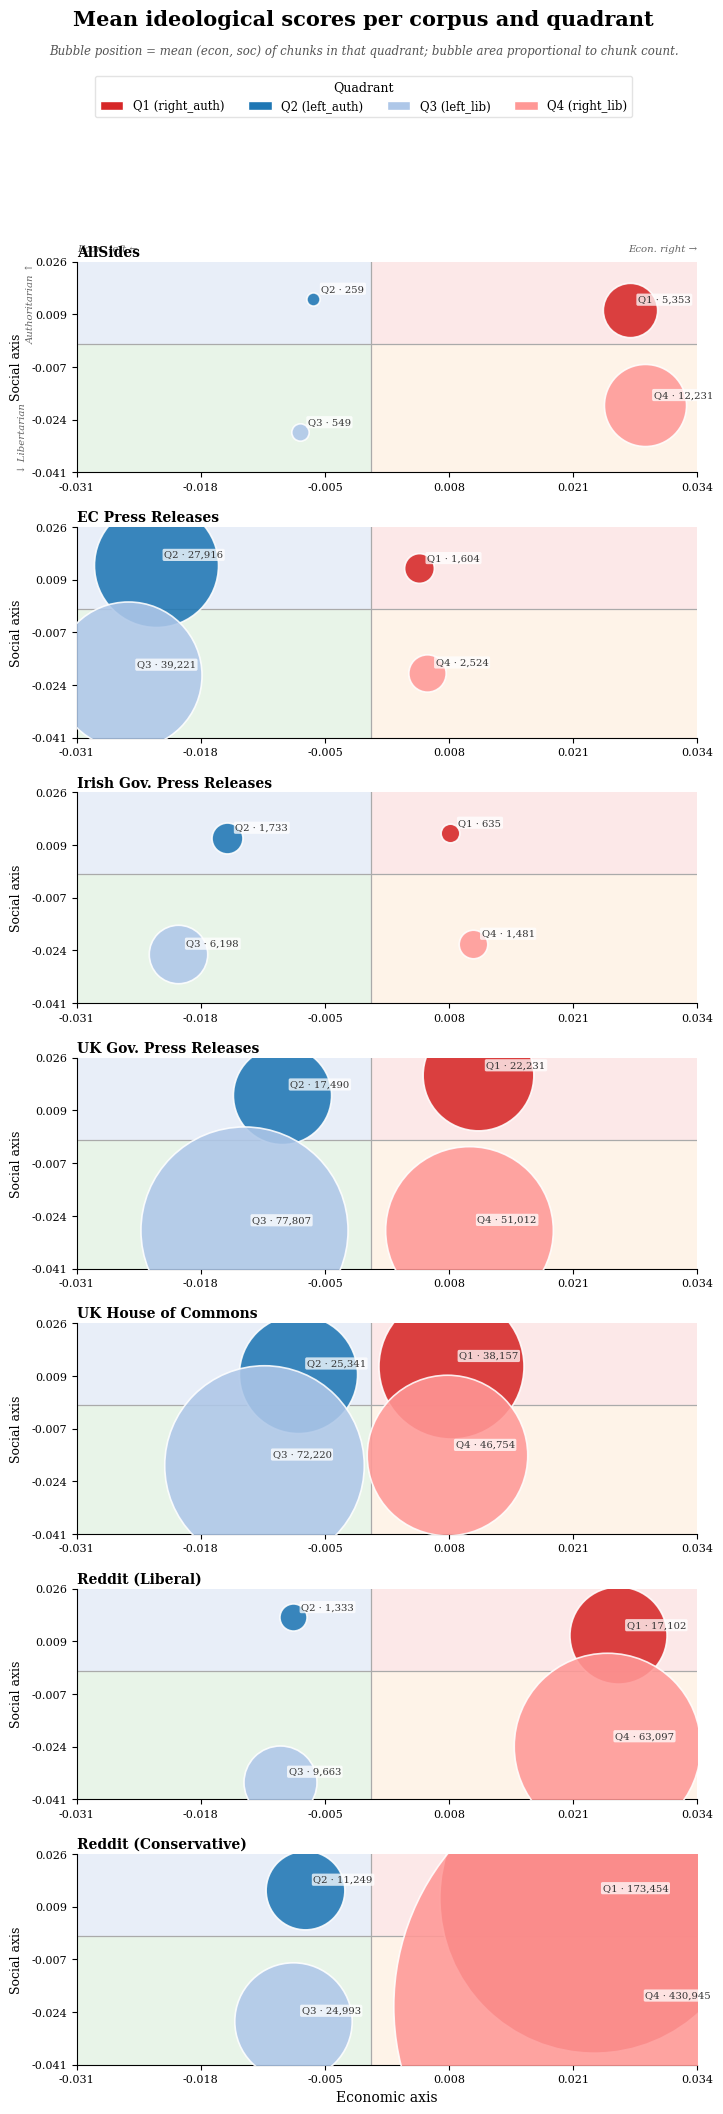

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

plt.rcParams.update({
    "font.family":       "serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# === GLOBAL ZOOM BASED ON ACTUAL DATA ===
x_all = df["mean_econ"].to_numpy()
y_all = df["mean_soc"].to_numpy()

x_pad = max((x_all.max() - x_all.min()) * 0.10, 0.002)
y_pad = max((y_all.max() - y_all.min()) * 0.10, 0.002)

xlim = (x_all.min() - x_pad, x_all.max() + x_pad)
ylim = (y_all.min() - y_pad, y_all.max() + y_pad)

n_src = len(SOURCES)
fig, axes = plt.subplots(
    n_src, 1,
    figsize=(7.4, 2.9 * n_src),
    sharex=True,
    sharey=True,
)

if n_src == 1:
    axes = [axes]

SIZE_SCALE = 3500

# fixed ticks for every subplot
xticks = np.linspace(xlim[0], xlim[1], 6)
yticks = np.linspace(ylim[0], ylim[1], 5)

for ax, source in zip(axes, SOURCES):
    sub = df[df["source"] == source].copy()

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()

    # quadrant background shading
    ax.add_patch(mpatches.Rectangle((0, 0), x1, y1,
                                    facecolor="#fce8e8", edgecolor="none", zorder=0))  # Q1
    ax.add_patch(mpatches.Rectangle((x0, 0), -x0, y1,
                                    facecolor="#e8eef8", edgecolor="none", zorder=0))  # Q2
    ax.add_patch(mpatches.Rectangle((x0, y0), -x0, -y0,
                                    facecolor="#e8f4e8", edgecolor="none", zorder=0))  # Q3
    ax.add_patch(mpatches.Rectangle((0, y0), x1, -y0,
                                    facecolor="#fef3e8", edgecolor="none", zorder=0))  # Q4

    # central axes
    ax.axhline(0, color="#aaaaaa", lw=0.9, zorder=1)
    ax.axvline(0, color="#aaaaaa", lw=0.9, zorder=1)

    # bubbles
    for _, row in sub.iterrows():
        q = row["quadrant"]
        me = row["mean_econ"]
        ms = row["mean_soc"]
        n = row["n_chunks"]

        ax.scatter(
            me,
            ms,
            s=max(n / SIZE_SCALE * 1000, 90),
            color=COLORS[q],
            alpha=0.88,
            edgecolors="white",
            linewidths=1.2,
            zorder=3,
        )

        ax.annotate(
            f"{Q_SHORT[q]} · {n:,}",
            xy=(me, ms),
            xytext=(6, 4),
            textcoords="offset points",
            fontsize=7.2,
            ha="left",
            va="bottom",
            color="#333",
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="none", alpha=0.75),
            zorder=4,
        )

    ax.set_title(SOURCE_LABEL[source], fontsize=10, fontweight="bold", loc="left", pad=4)
    ax.set_ylabel("Social axis", fontsize=9, labelpad=6)

    # numbered ticks on every subplot
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.tick_params(axis="x", labelbottom=True, labelsize=8)
    ax.tick_params(axis="y", labelleft=True, labelsize=8)

# x label on last axis, but ticks on all
axes[-1].set_xlabel("Economic axis", fontsize=10, labelpad=4)

# === CLEAN DIRECTION LABELS ONLY ON THE FIRST PANEL ===
ax0 = axes[0]
ax0.text(0.00, 1.04, "Econ. left \u2190",
         transform=ax0.transAxes, fontsize=7.3, color="#666",
         ha="left", va="bottom", style="italic")
ax0.text(1.00, 1.04, "Econ. right \u2192",
         transform=ax0.transAxes, fontsize=7.3, color="#666",
         ha="right", va="bottom", style="italic")

ax0.text(-0.08, 1.00, "Authoritarian \u2191",
         transform=ax0.transAxes, fontsize=7.3, color="#666",
         rotation=90, ha="left", va="top", style="italic")
ax0.text(-0.08, 0.00, "\u2193 Libertarian",
         transform=ax0.transAxes, fontsize=7.3, color="#666",
         rotation=90, ha="right", va="bottom", style="italic")

# legend
legend_handles = [
    mpatches.Patch(facecolor=COLORS[q], edgecolor="white", label=Q_LABEL[q])
    for q in QUADRANTS
]
fig.legend(
    handles=legend_handles,
    title="Quadrant",
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.01),
    fontsize=8.5,
    title_fontsize=9,
    frameon=True,
    edgecolor="#dddddd",
)

fig.suptitle(
    "Mean ideological scores per corpus and quadrant",
    fontsize=15,
    fontweight="bold",
    y=1.04,
)

fig.text(
    0.5,
    1.018,
    "Bubble position = mean (econ, soc) of chunks in that quadrant; bubble area proportional to chunk count.",
    ha="center",
    fontsize=8.5,
    color="#555",
    style="italic",
)

plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=1.2)
# plt.savefig(
#     "../data/experts/quadrant_pools/mean_scores_by_source.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )
plt.show()

## Score distributions — histograms of abs_econ, abs_soc, conf_margin
Useful for picking a retention threshold.

In [ ]:
random.seed(42)

all_rows = []
for source in SOURCES:
    path = BASE / source / "scored_chunks.jsonl"
    with open(path) as f:
        lines = f.readlines()
    sample = random.sample(lines, min(50_000, len(lines)))
    for line in sample:
        d = json.loads(line)
        all_rows.append({
            "source":   source,
            "quadrant": d["quadrant"],
            "abs_econ": d["score_abs_econ"],
            "abs_soc":  d["score_abs_soc"],
            "conf":     d["confidence_margin"],
        })

df_sample = pd.DataFrame(all_rows).dropna()
print(f"Sample size: {len(df_sample):,}")

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(9, 12))
bins = 80
cols = {
    "abs_econ": ("abs_econ score", "#1f77b4"),
    "abs_soc":  ("abs_soc score",  "#d62728"),
    "conf":     ("conf_margin",    "#2ca02c"),
}

for ax, (col, (label, color)) in zip(axes, cols.items()):
    vals = df_sample[col].values
    ax.hist(vals, bins=bins, color=color, alpha=0.75, edgecolor="white")
    for pct, ls in [(75, ":"), (90, "--"), (95, "-.")]:
        v = float(np.percentile(vals, pct))
        ax.axvline(v, color="black", lw=1.2, ls=ls, label=f"p{pct}={v:.3f}")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("score")
    ax.set_ylabel("count")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle("Score distributions (sample 50k/source) — dashed lines = candidate thresholds",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for source in SOURCES:
    vals = df_sample[df_sample["source"] == source]["conf"].values
    ax.hist(vals, bins=60, alpha=0.5, label=SOURCE_LABEL[source], density=True)

ax.set_title("conf_margin distribution per source (density)", fontweight="bold")
ax.set_xlabel("conf_margin")
ax.set_ylabel("density")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Threshold sensitivity — how many chunks survive at different cutoffs?

In [ ]:
thresholds = [0.005, 0.010, 0.015, 0.020, 0.025, 0.030, 0.040, 0.050]

rows = []
for t in thresholds:
    mask = (df_sample["abs_econ"] >= t) & (df_sample["abs_soc"] >= t) & (df_sample["conf"] >= t)
    n_pass = mask.sum()
    rows.append({"threshold": t, "n_pass": n_pass, "pct_pass": 100 * n_pass / len(df_sample)})

df_thresh = pd.DataFrame(rows)
print(df_thresh.to_string(index=False, float_format="{:.3f}".format))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_thresh["threshold"], df_thresh["pct_pass"], marker="o", color="#d62728")
ax.set_title("% chunks surviving threshold (all three axes)", fontweight="bold")
ax.set_xlabel("threshold (applied to abs_econ, abs_soc, conf_margin)")
ax.set_ylabel("% retained")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
for _, r in df_thresh.iterrows():
    ax.annotate(f"{r.pct_pass:.1f}%", (r.threshold, r.pct_pass),
                textcoords="offset points", xytext=(0, 7), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## Political compass — chunk scatter by source family
Each point is one sampled chunk at its (score_econ, score_soc) position.
Colour = broad source family: **Reddit**, **Press**, **Speeches (HoC)**.

In [20]:
from scipy.stats import gaussian_kde

random.seed(0)

FAMILY = {
    "reddit_liberal":      "Reddit",
    "reddit_conservative": "Reddit",
    "allsides":            "Press",
    "ec_press":            "Press",
    "ire_press":           "Press",
    "uk_press":            "Press",
    "hoc":                 "Speeches",
}
FAMILY_STYLE = {
    "Reddit":   {"color": "#e6194b", "marker": "o", "alpha": 0.25, "zorder": 3},
    "Press":    {"color": "#3cb44b", "marker": "s", "alpha": 0.25, "zorder": 2},
    "Speeches": {"color": "#4363d8", "marker": "^", "alpha": 0.35, "zorder": 4},
}

N_PER_SOURCE = 8_000

compass_points = {fam: {"econ": [], "soc": []} for fam in FAMILY_STYLE}

for source, family in FAMILY.items():
    path = BASE / source / "scored_chunks.jsonl"
    with open(path) as f:
        lines = f.readlines()
    sample = random.sample(lines, min(N_PER_SOURCE, len(lines)))
    for line in sample:
        d = json.loads(line)
        e, s = d["score_econ"], d["score_soc"]
        if e == e and s == s:
            compass_points[family]["econ"].append(e)
            compass_points[family]["soc"].append(s)

print("Points per family:")
for fam, pts in compass_points.items():
    print(f"  {fam}: {len(pts['econ']):,}")

Points per family:
  Reddit: 15,999
  Press: 31,997
  Speeches: 8,000


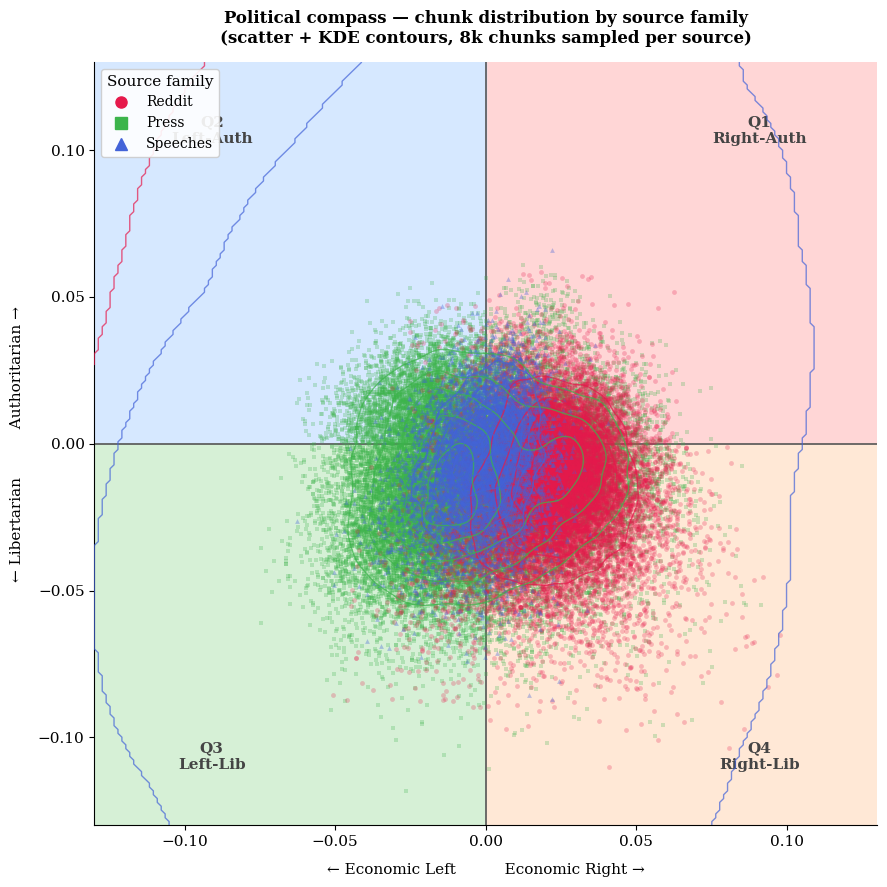

In [21]:
lim = 0.13

fig, ax = plt.subplots(figsize=(9, 9))

# quadrant background shading
ax.axhspan(0,    lim,  xmin=0.5, xmax=1,   color="#ffd6d6", zorder=0)  # Q1 right_auth
ax.axhspan(0,    lim,  xmin=0,   xmax=0.5, color="#d6e8ff", zorder=0)  # Q2 left_auth
ax.axhspan(-lim, 0,    xmin=0,   xmax=0.5, color="#d6f0d6", zorder=0)  # Q3 left_lib
ax.axhspan(-lim, 0,    xmin=0.5, xmax=1,   color="#ffe8d6", zorder=0)  # Q4 right_lib

ax.axhline(0, color="#555", lw=1.2, zorder=1)
ax.axvline(0, color="#555", lw=1.2, zorder=1)

# scatter
for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    ax.scatter(
        pts["econ"], pts["soc"],
        c=style["color"], marker=style["marker"],
        alpha=style["alpha"], s=12, linewidths=0, zorder=style["zorder"],
    )

# KDE contours
grid_x = np.linspace(-lim, lim, 200)
grid_y = np.linspace(-lim, lim, 200)
xx, yy = np.meshgrid(grid_x, grid_y)
grid_coords = np.vstack([xx.ravel(), yy.ravel()])

for fam, style in FAMILY_STYLE.items():
    pts = compass_points[fam]
    if len(pts["econ"]) < 100:
        continue
    kde = gaussian_kde(np.vstack([pts["econ"], pts["soc"]]), bw_method=0.15)
    zz  = kde(grid_coords).reshape(xx.shape)
    ax.contour(xx, yy, zz, levels=5, colors=style["color"], linewidths=1.0, alpha=0.7, zorder=5)

# quadrant corner labels
kw = dict(fontsize=11, fontweight="bold", color="#444", va="center", ha="center")
ax.text( lim * 0.7,  lim * 0.82, "Q1\nRight-Auth", **kw)
ax.text(-lim * 0.7,  lim * 0.82, "Q2\nLeft-Auth",  **kw)
ax.text(-lim * 0.7, -lim * 0.82, "Q3\nLeft-Lib",   **kw)
ax.text( lim * 0.7, -lim * 0.82, "Q4\nRight-Lib",  **kw)

ax.set_xlabel("← Economic Left          Economic Right →", fontsize=11, labelpad=10)
ax.set_ylabel("← Libertarian          Authoritarian →",   fontsize=11, labelpad=10)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

handles = [
    mlines.Line2D([], [], color=st["color"], marker=st["marker"],
                  linestyle="None", markersize=8, label=fam)
    for fam, st in FAMILY_STYLE.items()
]
ax.legend(handles=handles, title="Source family", fontsize=10, loc="upper left", framealpha=0.9)
ax.set_title(
    "Political compass — chunk distribution by source family\n"
    "(scatter + KDE contours, 8k chunks sampled per source)",
    fontsize=12, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.savefig("../data/experts/quadrant_pools/political_compass.png", dpi=150, bbox_inches="tight")
plt.show()